## Data Cleaning and Preprocessing

#### Import necessary Library

In [2]:
import pandas as pd
import numpy as np
import sqlite3

#### Pandas

In [ ]:
data1 = pd.read_csv("your_file.csv")
data2 = pd.read_csv("your_file.txt", delimiter=",")  # or "\t"
data3 = pd.read_excel("your_file.xlsx")

conn = sqlite3.connect(your_file.db)
data4 = pd.read_sql("SELECT * FROM your_table", conn)

### Numpy

In [ ]:
# import the NumPy library import numpy as np
# create a NumPy array
arr = np.array([1, 2, 3, 4, 5])

# perform element-wise operations arr2 = arr * 2


### 2.	Understanding Data Quality Issues

In [3]:
# Importing necessary library import pandas as pd

# Loading your dataset
df = pd.read_csv('traffic_mobility_data.csv') # Replace 'your_file.csv' with your filename
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0.0,-0.609199,2.0,45.0,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0.0,0.965442,16.0,1.0,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0.0,0.289660,16.0,49.0,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0.0,-0.271965,66.0,10.0,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0.0,-0.797606,3.0,5.0,364.466342,16.801459,Low


In [4]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"])

In [12]:
df.set_index("Timestamp",inplace=True)

In [5]:
df.duplicated().sum()

np.int64(0)

# Checking for missing values in each column

In [6]:
missing_values = df.isnull().sum() 
print(missing_values)

Timestamp                  0
Latitude                   9
Longitude                 11
Vehicle_Count              0
Traffic_Speed_kmh          2
Road_Occupancy_%           1
Traffic_Light_State        0
Weather_Condition          9
Accident_Report            8
Sentiment_Score            8
Ride_Sharing_Demand        8
Parking_Availability       8
Emission_Levels_g_km       8
Energy_Consumption_L_h     8
Traffic_Condition          9
dtype: int64


In [7]:
df.columns

Index(['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State',
       'Weather_Condition', 'Accident_Report', 'Sentiment_Score',
       'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Traffic_Condition'],
      dtype='object')

In [8]:
df.shape

(5008, 15)

In [9]:
df.size

75120

In [10]:
cols = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State']

duplicates = df[cols].sample(n=8, random_state=42)
df_with_duplicates = pd.concat([df, duplicates])#, ignore_index=True)

print("original_data:", df.shape)
print("duplicated_data:", df_with_duplicates.shape)

original_data: (5008, 15)
duplicated_data: (5016, 15)


In [11]:
print(df_with_duplicates.duplicated)

<bound method DataFrame.duplicated of                Timestamp   Latitude  Longitude  Vehicle_Count  \
0    2024-03-01 00:00:00  40.842275 -73.703149            205   
1    2024-03-01 00:05:00  40.831119 -73.987354            202   
2    2024-03-01 00:10:00  40.819549 -73.732462            252   
3    2024-03-01 00:15:00  40.725849 -73.980134             37   
4    2024-03-01 00:20:00  40.813265 -73.961631             64   
...                  ...        ...        ...            ...   
1609                 NaT        NaN        NaN            188   
3357                 NaT        NaN        NaN            224   
3956                 NaT        NaN        NaN             53   
584                  NaT        NaN        NaN            186   
1907                 NaT        NaN        NaN            234   

      Traffic_Speed_kmh  Road_Occupancy_% Traffic_Light_State  \
0             49.893435         82.652780              Yellow   
1             22.383965         45.829298          

In [12]:
df.isnull().sum()

Timestamp                  0
Latitude                   9
Longitude                 11
Vehicle_Count              0
Traffic_Speed_kmh          2
Road_Occupancy_%           1
Traffic_Light_State        0
Weather_Condition          9
Accident_Report            8
Sentiment_Score            8
Ride_Sharing_Demand        8
Parking_Availability       8
Emission_Levels_g_km       8
Energy_Consumption_L_h     8
Traffic_Condition          9
dtype: int64

### Which columns contains categorical and Numerical

In [13]:
numerical_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns=df.select_dtypes(include=['object','category']).columns.tolist()
print("Numerical Columns:\n",list(numerical_columns))
print("\nCategorical Columns:\n", list(categorical_columns))

Numerical Columns:
 ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Accident_Report', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h']

Categorical Columns:
 ['Traffic_Light_State', 'Weather_Condition', 'Traffic_Condition']


In [14]:
for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)

Traffic_Light_State:
['Yellow' 'Green' 'Red']
----------------------------------------
Weather_Condition:
['Clear' 'Rain' 'Fog' 'Snow' nan]
----------------------------------------
Traffic_Condition:
['High' 'Low' 'Medium' nan]
----------------------------------------


### See unique values in each categorical column

In [15]:
df[categorical_columns].nunique()

Traffic_Light_State    3
Weather_Condition      4
Traffic_Condition      3
dtype: int64

# Frequence Counting

In [16]:
for col in categorical_columns:
    #print(f"\n{col}")
    print(df[col].value_counts())

Traffic_Light_State
Yellow    1732
Green     1652
Red       1624
Name: count, dtype: int64
Weather_Condition
Rain     1278
Snow     1257
Fog      1245
Clear    1219
Name: count, dtype: int64
Traffic_Condition
High      3166
Medium    1474
Low        359
Name: count, dtype: int64


### Handling Duplicates and Redundant Data

In [17]:
# Check for duplicate rows duplicate_rows = df.duplicated()

# Count of duplicate rows
#print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# Drop the duplicates
df = df.drop_duplicates()

# Checking the shape of the data after dropping duplicates
print("Shape of DataFrame After Removing Duplicates: ", df.shape)

Shape of DataFrame After Removing Duplicates:  (5008, 15)


## Handling Missing Value

### Techniques Of Hundling Missing Value

## Multiple Imputation
* Multiple imputation is a statistical technique for handling missing data where the missing value is estimated multiple times. 

In [18]:
# Multiple Imputation by Chained Equations
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

# Initialize the MICE imputer
mice_imputer = IterativeImputer()

# Apply the imputer
df_imputed = mice_imputer.fit_transform(df[numerical_columns])


### Predictive Imputation

#### Drop Missing value

In [19]:
df=df.dropna()

In [20]:
df.shape

(4991, 15)

In [21]:
df.columns

Index(['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State',
       'Weather_Condition', 'Accident_Report', 'Sentiment_Score',
       'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Traffic_Condition'],
      dtype='object')

## Dealing With Outliers

In [22]:
# Example: Converting a column with numeric values stored as strings to numeric format
numerical_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()
# df['numerical_columns'] = pd.to_numeric(df['numerical_columns'], errors='coerce')

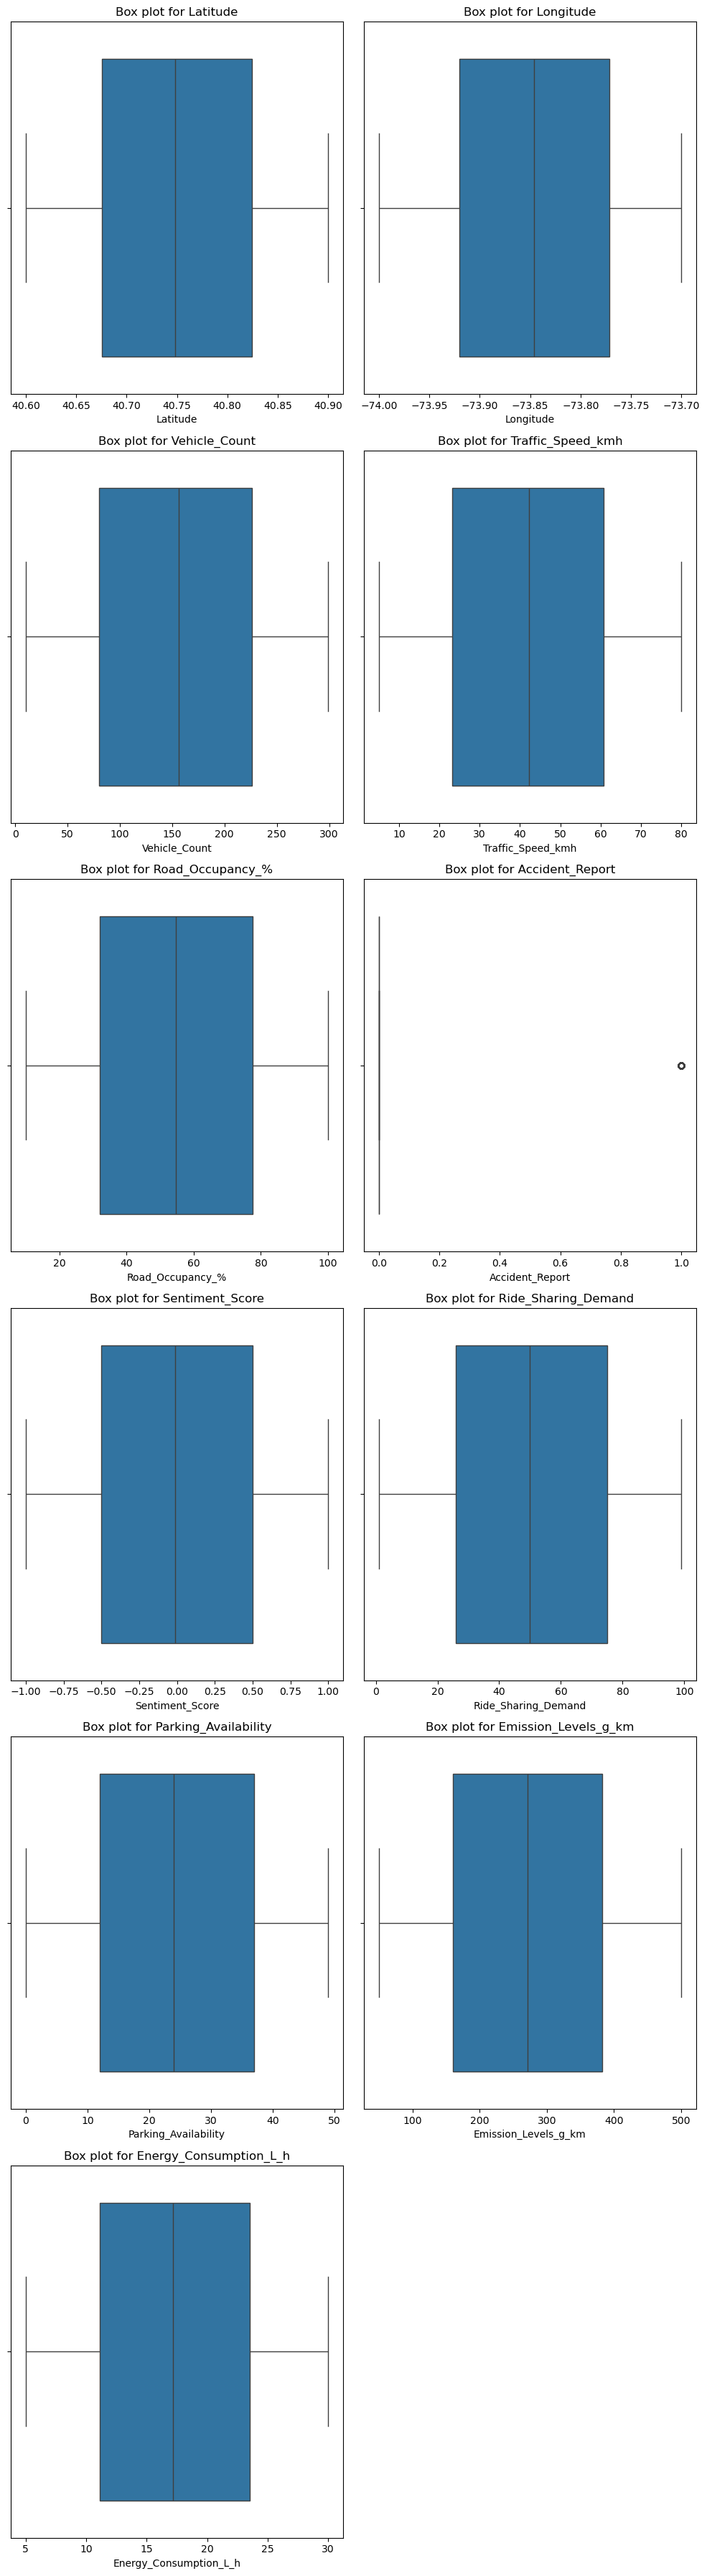

In [24]:
ncols = 2  
nrows = (len(numerical_columns) // ncols) + (len(numerical_columns) % ncols > 0)  # Calculate required rows

# Create subplots with a specific figure size
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6 * nrows))  # Adjust the height of the figure

# Flatten axes array for easier indexing (for cases where you have multiple rows)
axes = axes.flatten()

# Loop over numerical columns and create boxplots on each subplot
for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i])  # Specify the axis for each plot
    axes[i].set_title(f'Box plot for {col}')  # Add title to each subplot

# Hide any empty subplots if the total number of columns is not a perfect multiple of the subplot grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust spacing for better layout
plt.show()

In [25]:
df.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,4991,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000
mean,2024-03-09 16:18:25.570025984,40.749579,-73.847471,154.019435,42.124717,54.763171,0.096173,-0.005889,50.467642,24.595873,272.066727,17.342087
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787
25%,2024-03-05 08:02:30,40.675309,-73.920286,80.000000,23.234399,32.104269,0.000000,-0.500252,26.000000,12.000000,160.491659,11.097834
50%,2024-03-09 16:25:00,40.748536,-73.846166,156.000000,42.247838,54.672767,0.000000,-0.011195,50.000000,24.000000,271.777187,17.156326
75%,2024-03-14 00:27:30,40.824713,-73.771725,226.000000,60.752933,77.582318,0.000000,0.500092,75.000000,37.000000,382.213113,23.517230
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416
std,NaN,0.086114,0.086210,83.487651,21.701452,26.144560,0.294858,0.583737,28.490566,14.527852,130.077951,7.210580


## Outliers Detection Method

In [26]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[numerical_columns])) 
outliers = df[(z_scores > 3)]

In [27]:
outliers

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
35,2024-03-01 02:55:00,40.690474,-73.972801,57,78.346608,10.343837,Red,Rain,1.0,0.386953,65.0,34.0,427.393369,11.745138,High
39,2024-03-01 03:15:00,40.765968,-73.951066,120,28.454281,88.916259,Red,Rain,1.0,-0.120263,73.0,41.0,388.632802,17.314708,High
47,2024-03-01 03:55:00,40.808723,-73.864981,271,23.190553,45.034081,Green,Snow,1.0,0.671850,1.0,40.0,245.086229,21.339772,High
59,2024-03-01 04:55:00,40.738817,-73.987311,293,32.265041,92.770276,Green,Snow,1.0,-0.939421,64.0,0.0,162.553416,18.598367,High
63,2024-03-01 05:15:00,40.887089,-73.725194,14,18.708037,42.968125,Yellow,Snow,1.0,-0.800814,11.0,27.0,243.717069,21.627124,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4951,2024-03-18 04:35:00,40.846859,-73.709168,160,63.613505,77.943134,Yellow,Fog,1.0,-0.825746,13.0,19.0,311.700865,11.247988,High
4963,2024-03-18 05:35:00,40.881499,-73.976865,176,48.635572,36.236719,Green,Rain,1.0,0.167595,6.0,1.0,456.999821,10.092012,High
4966,2024-03-18 05:50:00,40.735303,-73.725869,127,77.532237,72.914440,Yellow,Rain,1.0,0.611010,26.0,23.0,220.902416,29.024096,High
4971,2024-03-18 06:15:00,40.793425,-73.779791,178,9.367363,42.098383,Red,Clear,1.0,0.142065,81.0,44.0,164.296422,15.090137,High


In [28]:
Q1 = np.percentile(df[numerical_columns], 25) 
Q3 = np.percentile(df[numerical_columns], 75)
IQR = Q3 - Q1

outliers = df[numerical_columns][((df[numerical_columns] < (Q1 - 1.5 * IQR)) | (df[numerical_columns] > (Q3 + 1.5 * IQR)))]
outliers

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
0,NaN,NaN,205.0,NaN,NaN,NaN,NaN,NaN,NaN,450.760055,NaN
1,NaN,NaN,202.0,NaN,NaN,NaN,NaN,NaN,NaN,321.800341,NaN
2,NaN,NaN,252.0,NaN,NaN,NaN,NaN,NaN,NaN,231.152655,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.384292,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364.466342,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,NaN,266.0,NaN,NaN,NaN,NaN,NaN,NaN,252.070807,NaN
4996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.563872,NaN
4997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,442.692618,NaN


In [29]:
np.arange(len(df[numerical_columns])), df[numerical_columns]

(array([   0,    1,    2, ..., 4988, 4989, 4990], shape=(4991,)),
        Latitude  Longitude  Vehicle_Count  Traffic_Speed_kmh  \
 0     40.842275 -73.703149            205          49.893435   
 1     40.831119 -73.987354            202          22.383965   
 2     40.819549 -73.732462            252          46.889699   
 3     40.725849 -73.980134             37           5.730536   
 4     40.813265 -73.961631             64          61.348034   
 ...         ...        ...            ...                ...   
 4995  40.604663 -73.831032            266          22.987611   
 4996  40.733790 -73.752213             20          75.736987   
 4997  40.821354 -73.759376             43          59.492981   
 4998  40.772343 -73.836698             88          25.901119   
 4999  40.756688 -73.849335            147          51.473769   
 
       Road_Occupancy_%  Accident_Report  Sentiment_Score  Ride_Sharing_Demand  \
 0            82.652780              0.0        -0.609199             

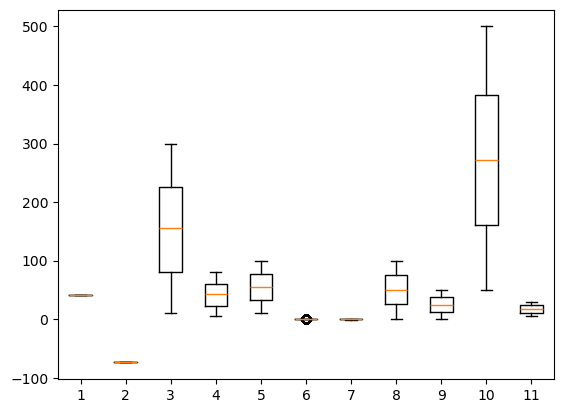

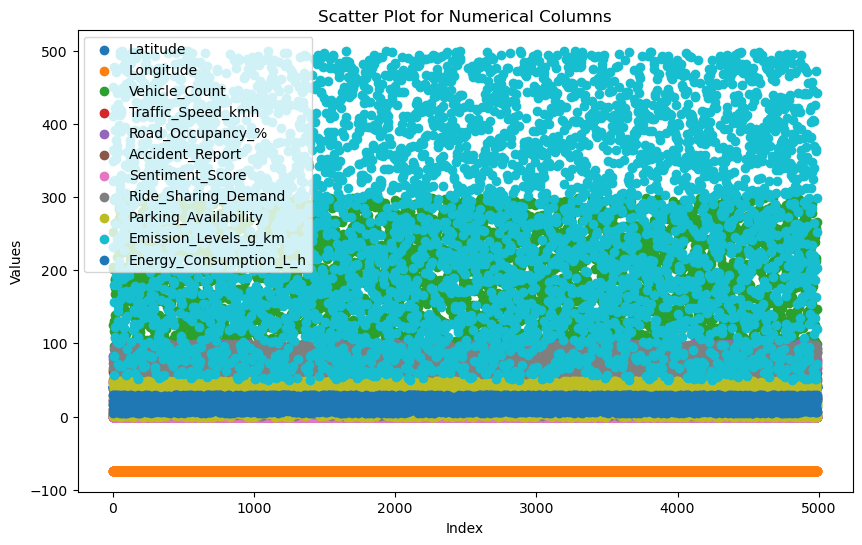

In [72]:
import matplotlib.pyplot as plt

# Boxplot 
plt.boxplot(df[numerical_columns]) 
plt.show()

# Create a scatter plot for each numerical column
plt.figure(figsize=(10, 6))

for col in numerical_columns:
    plt.scatter(range(len(df[col])), df[col], label=col)  # Plot values against index

plt.title("Scatter Plot for Numerical Columns")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()  # Show legend with column names
plt.show()


### 5) Exploratory Data Analysis
#### 5.1 Univariate Analysis (One Variable)

* Objective:

* Understand each variable individually

* Numerical Variables

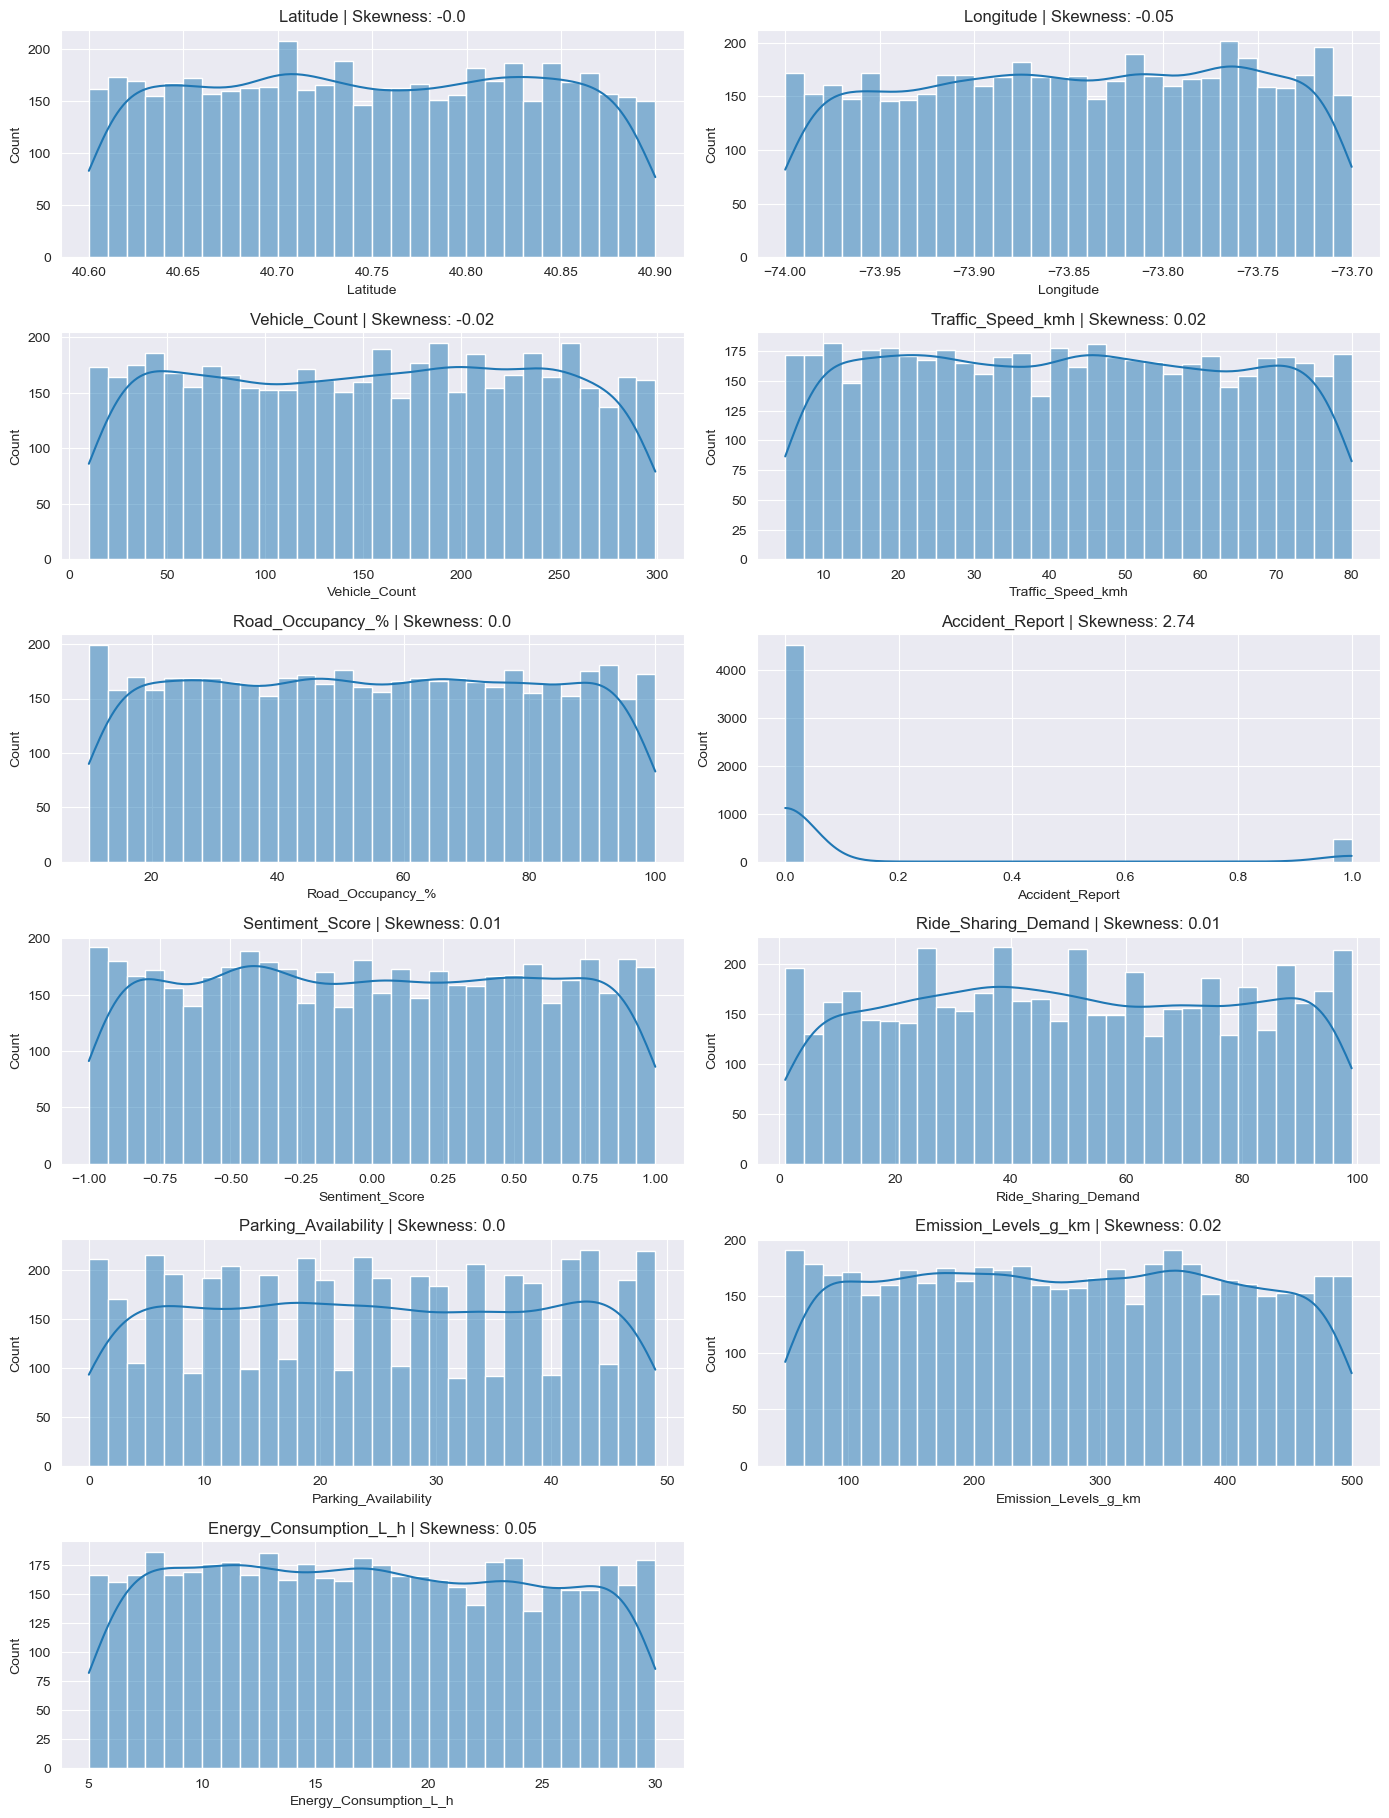

In [30]:
sns.set_style("darkgrid")

#numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))

for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    
    sns.histplot(df[feature], kde=True, bins=30)
    
    skewness = df[feature].skew()
    plt.title(f"{feature} | Skewness: {round(skewness, 2)}")

plt.tight_layout()
plt.show()

* What this does:
     * Loops through all numerical variables
* Plots:
    * Histogram → distribution
    * KDE → smooth curve
* Shows skewness

* Example:

    * Vehicle_Count right-skewed → occasional heavy congestion
    * Traffic_Speed_kmh left-skewed → frequent slow traffic
#### Add Boxplots (Important for Outliers)
### Detect:

    * Extreme congestion events
    * Abnormal sensor readings
## Categorical Univariate Analysis

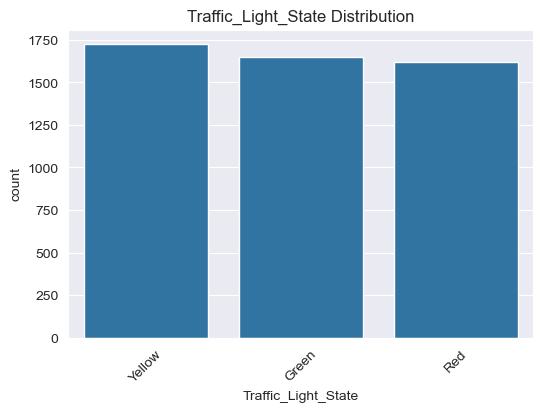

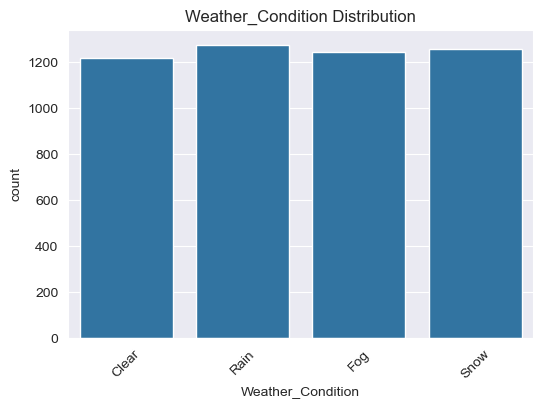

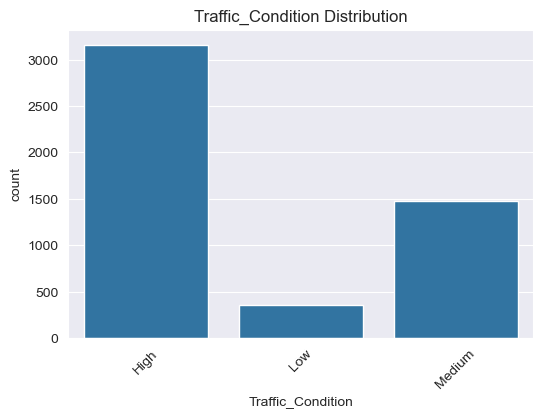

In [31]:
#categorical_columns = df.select_dtypes(include=['category', 'object']).columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

#### 2) BIVARIATE ANALYSIS (Fixed + Expanded)

### Pair plot

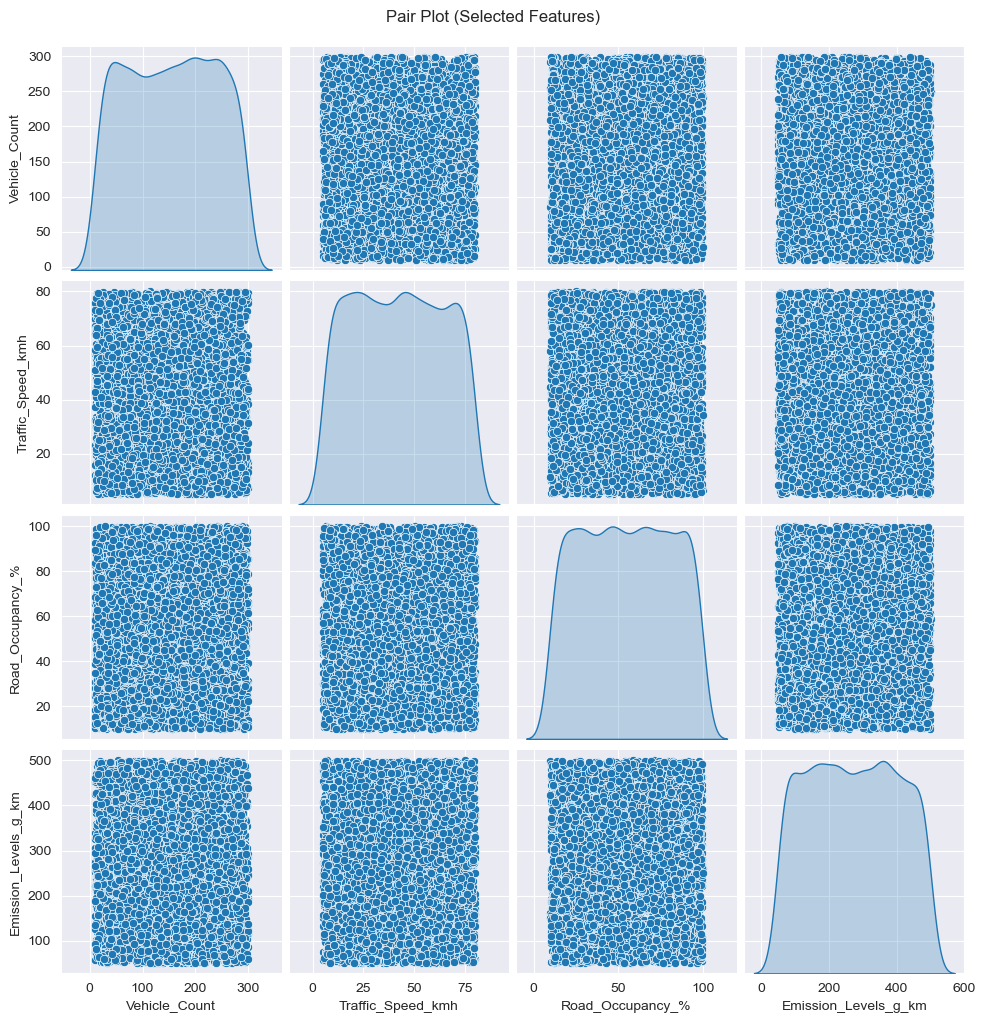

In [32]:
selected_features = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Emission_Levels_g_km']

sns.pairplot(df[selected_features], diag_kind='kde')
plt.suptitle('Pair Plot (Selected Features)', y=1.02)
plt.show()

### Explanation

#### Shows:

    * Relationships between variables
    * Linear / non-linear patterns
    * Clusters (e.g., high congestion zones)
### Scatter Plot (Key Transport Insight)

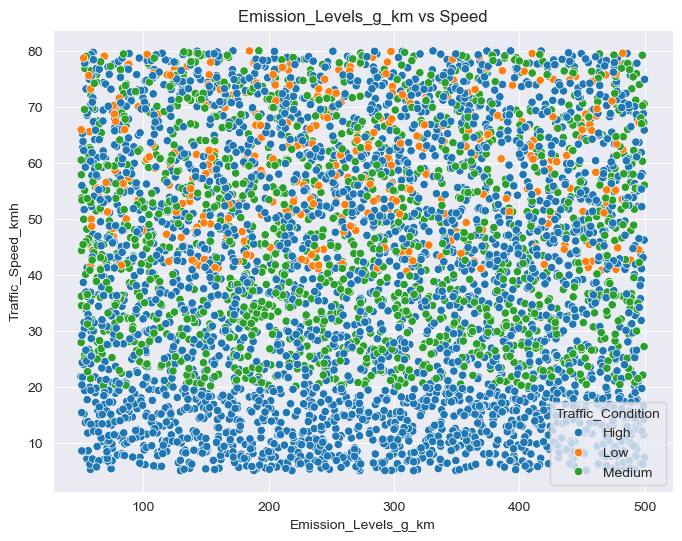

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Emission_Levels_g_km',
    y='Traffic_Speed_kmh',
    hue='Traffic_Condition',
    data=df
)
plt.title("Emission_Levels_g_km vs Speed")
plt.show()

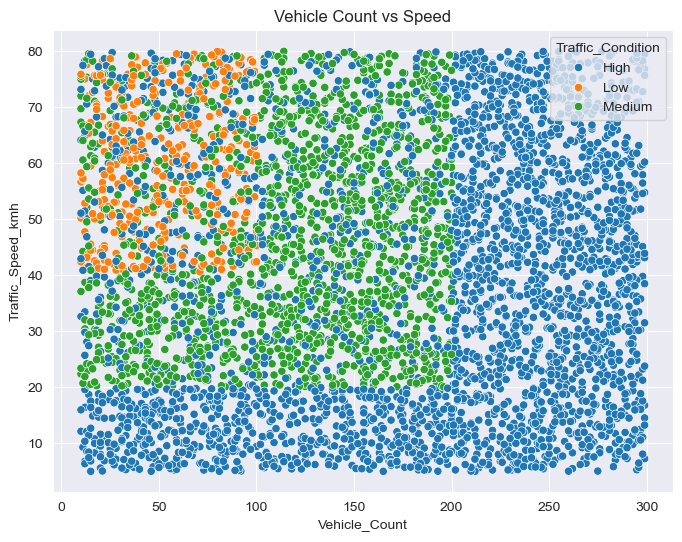

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Vehicle_Count',
    y='Traffic_Speed_kmh',
    hue='Traffic_Condition',
    data=df
)

plt.title("Vehicle Count vs Speed")
plt.show()

### Interpretation:

   * High vehicles + low speed → congestion
   * Color shows traffic condition impact
## Categorical vs Numerical

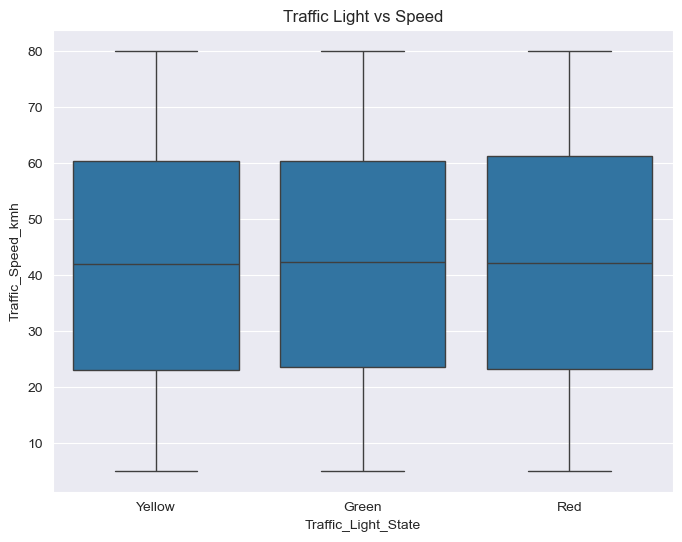

In [35]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Traffic_Light_State',
    y='Traffic_Speed_kmh',
    data=df
)

plt.title("Traffic Light vs Speed")
plt.show()

### Whether Impact

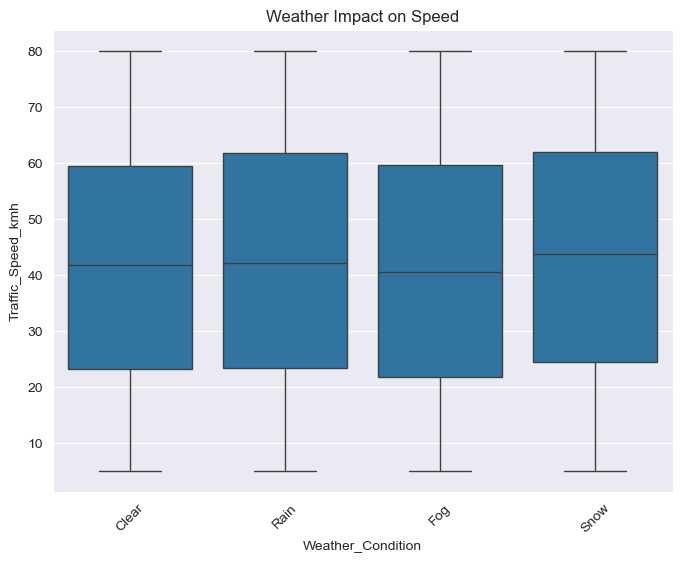

In [36]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Weather_Condition',
    y='Traffic_Speed_kmh',
    data=df
)
plt.xticks(rotation=45)
plt.title("Weather Impact on Speed")
plt.show()

## 3) MULTIVARIATE ANALYSIS (FIXED CODE)

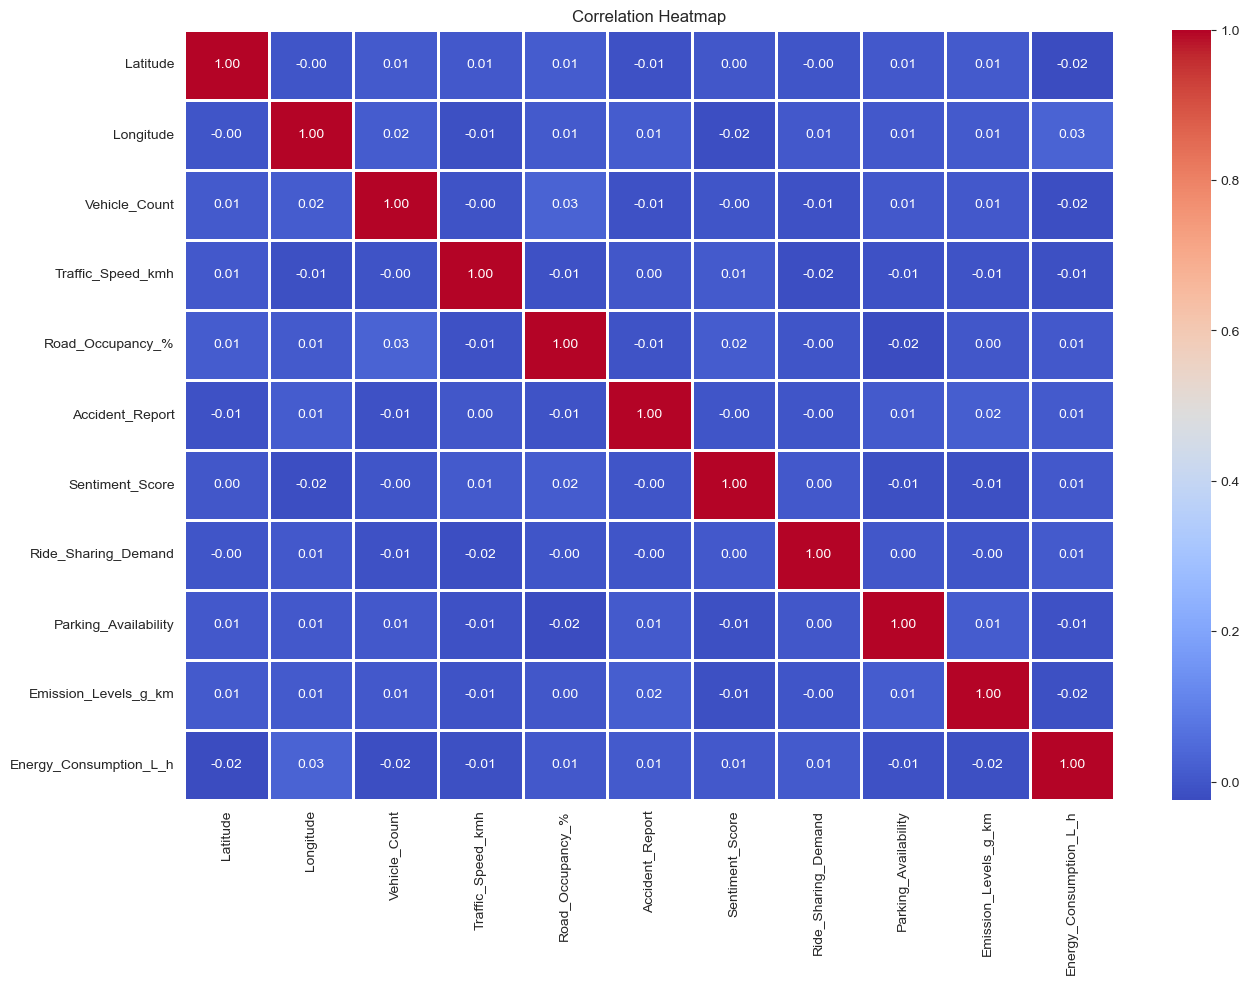

In [37]:
plt.figure(figsize=(15, 10))

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

corr_matrix = df[numerical_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=1
)

plt.title('Correlation Heatmap')
plt.show()

### Interpretation

* Look for:

   * Strong Positive Correlation:
   * Vehicle_Count ↑ → Road_Occupancy_% ↑
   * Strong Negative:
   * Vehicle_Count ↑ → Speed ↓

### Advanced Multivariate: Group Analysis

In [38]:
grouped = df.groupby('Traffic_Condition')[numerical_columns].mean()
print(grouped)

                    Latitude  Longitude  Vehicle_Count  Traffic_Speed_kmh  \
Traffic_Condition                                                           
High               40.749477 -73.847195     182.556469          37.888012   
Low                40.747833 -73.858029      53.366947          59.837058   
Medium             40.750221 -73.845505     117.174474          46.923712   

                   Road_Occupancy_%  Accident_Report  Sentiment_Score  \
Traffic_Condition                                                       
High                      60.683526         0.151851         0.002645   
Low                       29.573246         0.000000        -0.062919   
Medium                    48.163416         0.000000        -0.010382   

                   Ride_Sharing_Demand  Parking_Availability  \
Traffic_Condition                                              
High                         50.790573             24.604872   
Low                          49.994398             23.33

### Time-Based Analysis (VERY IMPORTANT)

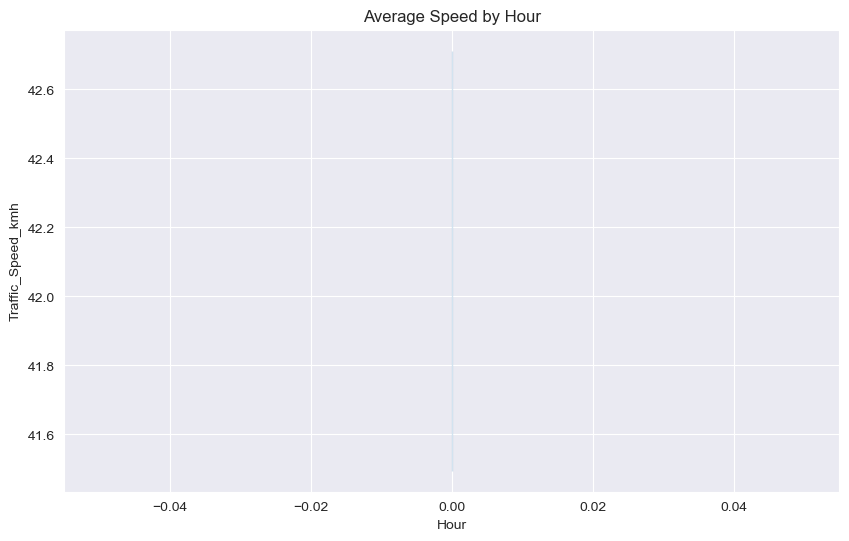

In [39]:
df['Timestamp'] = pd.to_datetime(df.index, errors='coerce')

df['Hour'] = df['Timestamp'].dt.hour

plt.figure(figsize=(10,6))

sns.lineplot(x='Hour', y='Traffic_Speed_kmh', data=df)

plt.title("Average Speed by Hour")
plt.show()

In [40]:
df.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Hour
count,4991,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.0
mean,1970-01-01 00:00:00.000002499,40.749579,-73.847471,154.019435,42.124717,54.763171,0.096173,-0.005889,50.467642,24.595873,272.066727,17.342087,0.0
min,1970-01-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787,0.0
25%,1970-01-01 00:00:00.000001248,40.675309,-73.920286,80.000000,23.234399,32.104269,0.000000,-0.500252,26.000000,12.000000,160.491659,11.097834,0.0
50%,1970-01-01 00:00:00.000002501,40.748536,-73.846166,156.000000,42.247838,54.672767,0.000000,-0.011195,50.000000,24.000000,271.777187,17.156326,0.0
75%,1970-01-01 00:00:00.000003749,40.824713,-73.771725,226.000000,60.752933,77.582318,0.000000,0.500092,75.000000,37.000000,382.213113,23.517230,0.0
max,1970-01-01 00:00:00.000004999,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416,0.0
std,NaN,0.086114,0.086210,83.487651,21.701452,26.144560,0.294858,0.583737,28.490566,14.527852,130.077951,7.210580,0.0


In [42]:
df.isnull().sum()

Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
Hour                      0
dtype: int64

In [44]:
df.shape

(4991, 16)

In [46]:
df.set_index(["Timestamp"],inplace=True)

In [47]:
df.head()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,Hour
Timestamp,,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0.0,-0.609199,2.0,45.0,450.760055,19.574337,High,0
1970-01-01 00:00:00.000000001,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0.0,0.965442,16.0,1.0,321.800341,5.385554,High,0
1970-01-01 00:00:00.000000002,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0.0,0.289660,16.0,49.0,231.152655,10.277477,High,0
1970-01-01 00:00:00.000000003,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0.0,-0.271965,66.0,10.0,410.384292,29.243279,High,0
1970-01-01 00:00:00.000000004,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0.0,-0.797606,3.0,5.0,364.466342,16.801459,Low,0


# encodeing the categorical columns

In [51]:
cal_col=df.select_dtypes(include=["object","category"]).columns.tolist()

In [52]:
cal_col

['Traffic_Light_State', 'Weather_Condition', 'Traffic_Condition']

In [61]:
for col in cal_col:
    print(df[col].value_counts())

Traffic_Light_State
Yellow    1723
Green     1648
Red       1620
Name: count, dtype: int64
Weather_Condition
Rain     1274
Snow     1257
Fog      1242
Clear    1218
Name: count, dtype: int64
Traffic_Condition
High      3161
Medium    1473
Low        357
Name: count, dtype: int64


In [64]:
weather_map = {
    'Clear': 0,
    'Snow': 1,
    'Fog': 3,
    'Rain': 4
}
signal_map = {
    'Red': 1,
    'Yellow': 2,
    'Green': 0
}
traffic_map={
    'High':2,
    'Medium':1,
    'Low':0

}
    
df["Weather_Condition"] = df["Weather_Condition"].map(weather_map)
df["Traffic_Light_State"] = df["Traffic_Light_State"].map(signal_map)
df["Traffic_Condition"] = df["Traffic_Condition"].map(traffic_map)

In [65]:
df.head()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,Hour
Timestamp,,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,40.842275,-73.703149,205,49.893435,82.652780,2,0,0.0,-0.609199,2.0,45.0,450.760055,19.574337,2,0
1970-01-01 00:00:00.000000001,40.831119,-73.987354,202,22.383965,45.829298,0,0,0.0,0.965442,16.0,1.0,321.800341,5.385554,2,0
1970-01-01 00:00:00.000000002,40.819549,-73.732462,252,46.889699,82.772465,0,4,0.0,0.289660,16.0,49.0,231.152655,10.277477,2,0
1970-01-01 00:00:00.000000003,40.725849,-73.980134,37,5.730536,37.695567,1,3,0.0,-0.271965,66.0,10.0,410.384292,29.243279,2,0
1970-01-01 00:00:00.000000004,40.813265,-73.961631,64,61.348034,22.313358,1,1,0.0,-0.797606,3.0,5.0,364.466342,16.801459,0,0


In [66]:
X = df.drop(["Traffic_Condition"],axis=1).values  # numpy array of x's
y = df["Traffic_Condition"].values

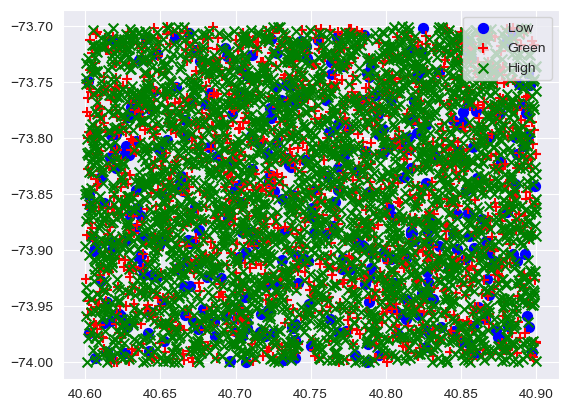

In [68]:
m, n = X.shape  # rows and columns

c0 = (y == 0).reshape(m, 1)
c1 = (y == 1).reshape(m, 1)
c2 = (y == 2).reshape(m, 1)

plt.scatter(X[c0[:, 0], 0], X[c0[:, 0], 1], c="b", marker="o", s=50, label="Low")
plt.scatter(X[c1[:, 0], 0], X[c1[:, 0], 1], c="r", marker="+", s=50, label="Green")
plt.scatter(X[c2[:, 0], 0], X[c2[:, 0], 1], c="g", marker="x", s=50, label="High")

plt.legend()

In [72]:
df.head()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,Hour
Timestamp,,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,40.842275,-73.703149,205,49.893435,82.652780,2,0,0.0,-0.609199,2.0,45.0,450.760055,19.574337,2,0
1970-01-01 00:00:00.000000001,40.831119,-73.987354,202,22.383965,45.829298,0,0,0.0,0.965442,16.0,1.0,321.800341,5.385554,2,0
1970-01-01 00:00:00.000000002,40.819549,-73.732462,252,46.889699,82.772465,0,4,0.0,0.289660,16.0,49.0,231.152655,10.277477,2,0
1970-01-01 00:00:00.000000003,40.725849,-73.980134,37,5.730536,37.695567,1,3,0.0,-0.271965,66.0,10.0,410.384292,29.243279,2,0
1970-01-01 00:00:00.000000004,40.813265,-73.961631,64,61.348034,22.313358,1,1,0.0,-0.797606,3.0,5.0,364.466342,16.801459,0,0
